# Lab 4: KNN Classification & Evaluation Metrics

## Task 1: Data Preparation

Import libraries, load Breast Cancer dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

RANDOM_STATE = 489
np.random.seed(RANDOM_STATE)

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Features: {X.shape}, Target: {y.shape}")
print(f"Classes: {target_names}")
print(f"Distribution: {pd.Series(y).value_counts().to_dict()}")

Features: (569, 30), Target: (569,)
Classes: ['malignant' 'benign']
Distribution: {1: 357, 0: 212}


### 1.1 Dataset Structure

Show dataset structure, check for missing values and duplicates.

In [2]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
display(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Missing values: 0
Duplicate rows: 0


### 1.2 Class Distribution & Balancing

Dataset has moderate imbalance (63% benign, 37% malignant). We apply **random oversampling** on the minority class.

Plot class distribution to visualize imbalance.

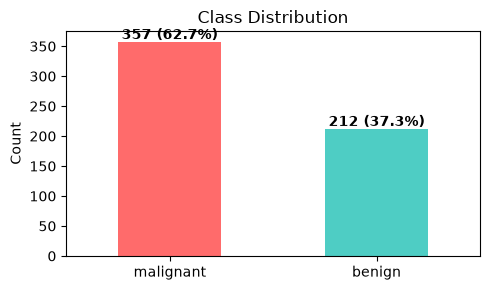

Ratio: 1:0.59 (benign:malignant)


In [3]:
class_counts = pd.Series(y).value_counts()
class_counts.index = target_names

fig, ax = plt.subplots(figsize=(5, 3))
class_counts.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'], rot=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, f'{v} ({v/len(y)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Ratio: 1:{class_counts.min()/class_counts.max():.2f} (benign:malignant)")

### 1.3 Feature Scaling

Standardize features (mean=0, std=1). Required because KNN uses distance calculations.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean after scaling (first 5): {X_scaled.mean(axis=0).round(2)[:5]}")
print(f"Std after scaling (first 5):  {X_scaled.std(axis=0).round(2)[:5]}")
print(f"Before: {X[0, :5].round(1)}  -> After: {X_scaled[0, :5].round(3)}")

Mean after scaling (first 5): [-0. -0. -0. -0.  0.]
Std after scaling (first 5):  [1. 1. 1. 1. 1.]
Before: [1.800e+01 1.040e+01 1.228e+02 1.001e+03 1.000e-01]  -> After: [ 1.097 -2.073  1.27   0.984  1.568]


### 1.4 Oversample Minority Class

Randomly duplicate malignant samples until both classes are equal size.

In [5]:
# Random oversampling: duplicate minority class to match majority
np.random.seed(RANDOM_STATE)
idx_0 = np.where(y == 0)[0]  # malignant
idx_1 = np.where(y == 1)[0]  # benign

n_target = len(idx_1)  # match majority class size
oversample_idx = np.random.choice(idx_0, size=n_target - len(idx_0), replace=True)
balanced_idx = np.concatenate([np.arange(len(y)), oversample_idx])

X_balanced = X_scaled[balanced_idx]
y_balanced = y[balanced_idx]

print(f"Before: {dict(pd.Series(y).value_counts())}")
print(f"After:  {dict(pd.Series(y_balanced).value_counts())}")
print(f"Total samples: {len(y)} -> {len(y_balanced)} (+{len(y_balanced)-len(y)} duplicates)")

Before: {1: np.int64(357), 0: np.int64(212)}
After:  {0: np.int64(357), 1: np.int64(357)}
Total samples: 569 -> 714 (+145 duplicates)


## Task 2: Train-Test Split Analysis

Compare KNN accuracy across 80:20, 70:30, and 90:10 train/test splits.

In [6]:
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
results_splits = {}

for name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_balanced, y_balanced, test_size=test_size, random_state=RANDOM_STATE)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    results_splits[name] = {'test_size': test_size, 'accuracy': acc,
                            'train': len(X_tr), 'test': len(X_te)}
    print(f"{name}: Train={len(X_tr)}, Test={len(X_te)}, Accuracy={acc:.4f}")

display(pd.DataFrame(results_splits).T)

80:20: Train=571, Test=143, Accuracy=0.9790
70:30: Train=499, Test=215, Accuracy=0.9581
90:10: Train=642, Test=72, Accuracy=0.9861


,test_size,accuracy,train,test
80:20,0.2,0.979021,571.0,143.0
70:30,0.3,0.958140,499.0,215.0
90:10,0.1,0.986111,642.0,72.0


**Split analysis:** 90:10 scores highest but test set is too small. 70:30 loses training data. 80:20 is the standard balanced choice.

## Task 3: KNN with Heuristic K Selection

Split data 80:20, compute heuristic K = sqrt(n). K must be **odd** to avoid ties in majority voting.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=RANDOM_STATE
)

K_heuristic = int(np.sqrt(len(X_train)))
print(f"Training samples: {len(X_train)}")
print(f"Heuristic K = sqrt({len(X_train)}) = {K_heuristic}")

Training samples: 571
Heuristic K = sqrt(571) = 23


### 3.1 Accuracy vs K (Heuristic +/- 10)

Test K values from heuristic-10 to +10, plot accuracy to find optimal K.

K=13  Accuracy=0.9720
K=14  Accuracy=0.9580
K=15  Accuracy=0.9650
K=16  Accuracy=0.9650
K=17  Accuracy=0.9720
K=18  Accuracy=0.9790
K=19  Accuracy=0.9790
K=20  Accuracy=0.9790
K=21  Accuracy=0.9790
K=22  Accuracy=0.9790
K=23  Accuracy=0.9790
K=24  Accuracy=0.9790
K=25  Accuracy=0.9650
K=26  Accuracy=0.9650
K=27  Accuracy=0.9650
K=28  Accuracy=0.9650
K=29  Accuracy=0.9650
K=30  Accuracy=0.9720
K=31  Accuracy=0.9580
K=32  Accuracy=0.9790
K=33  Accuracy=0.9580


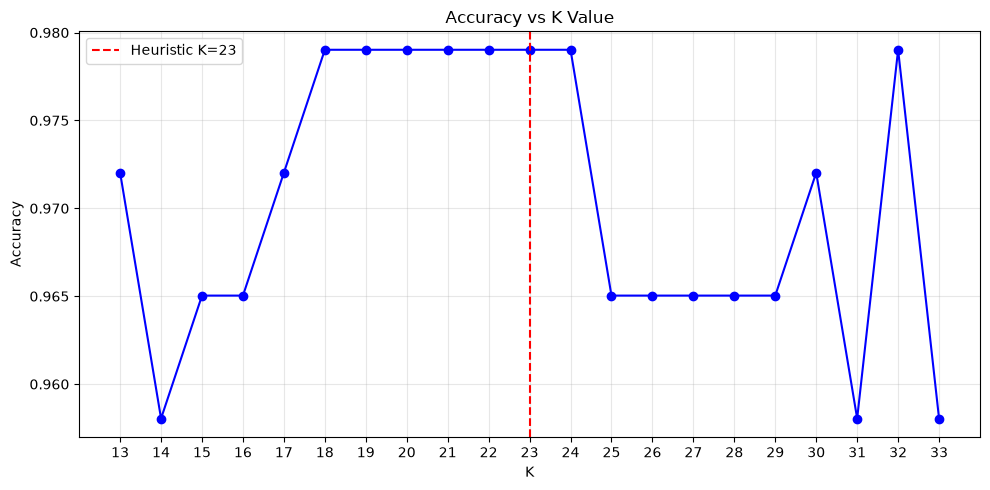

Best K (simple): 18 (accuracy=0.9790)


In [8]:
K_range = list(range(max(1, K_heuristic - 10), K_heuristic + 11))
accuracy_values = []

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracy_values.append(acc)
    print(f"K={k:2d}  Accuracy={acc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, accuracy_values, marker='o', color='b')
plt.axvline(x=K_heuristic, color='r', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=150)
plt.show()

best_k_simple = K_range[np.argmax(accuracy_values)]
print(f"Best K (simple): {best_k_simple} (accuracy={max(accuracy_values):.4f})")

**K and bias-variance:** K=1 overfits, large K underfits. Mid-range K balances the tradeoff.

### 3.2 Distance Metrics

Compare 5 distance metrics: Euclidean, Manhattan, Minkowski, Chebyshev, Cosine.

euclidean       | Acc=0.9790 Prec=0.9759 Rec=0.9878 F1=0.9818
manhattan       | Acc=0.9720 Prec=0.9756 Rec=0.9756 F1=0.9756
minkowski_p3    | Acc=0.9650 Prec=0.9639 Rec=0.9756 F1=0.9697
chebyshev       | Acc=0.9301 Prec=0.9390 Rec=0.9390 F1=0.9390
cosine          | Acc=0.9580 Prec=0.9634 Rec=0.9634 F1=0.9634


/Users/dan/projects/pythonVishal/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)


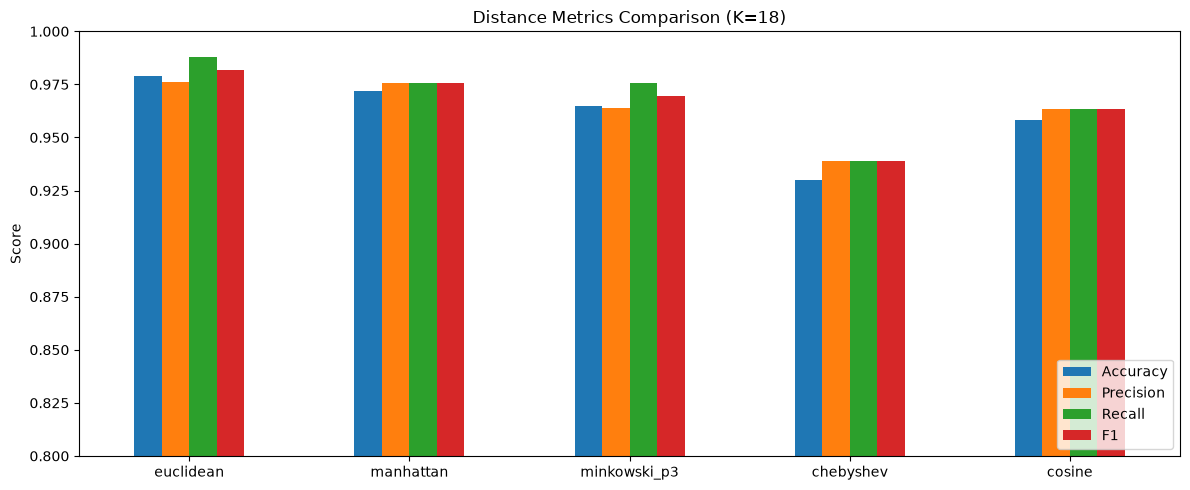

In [9]:
metrics = {
    'euclidean': {'metric': 'euclidean'},
    'manhattan': {'metric': 'manhattan'},
    'minkowski_p3': {'metric': 'minkowski', 'p': 3},
    'chebyshev': {'metric': 'chebyshev'},
    'cosine': {'metric': 'cosine'},
}

metric_results = {}
K_test = best_k_simple

for name, params in metrics.items():
    knn = KNeighborsClassifier(n_neighbors=K_test, metric=params['metric'],
                               metric_params={k: v for k, v in params.items() if k != 'metric'})
    knn.fit(X_train, y_train)
    y_pred_m = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_m)
    prec = precision_score(y_test, y_pred_m)
    rec = recall_score(y_test, y_pred_m)
    f1 = f1_score(y_test, y_pred_m)
    metric_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"{name:15s} | Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}")

metrics_df = pd.DataFrame(metric_results).T

# Bar plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
metrics_df.plot(kind='bar', ax=ax, rot=0)
plt.title(f'Distance Metrics Comparison (K={K_test})')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('distance_metrics_comparison.png', dpi=150)
plt.show()

### 3.3 Decision Boundaries

Plot decision boundaries for K=1,5,10,20 using PCA and raw features.

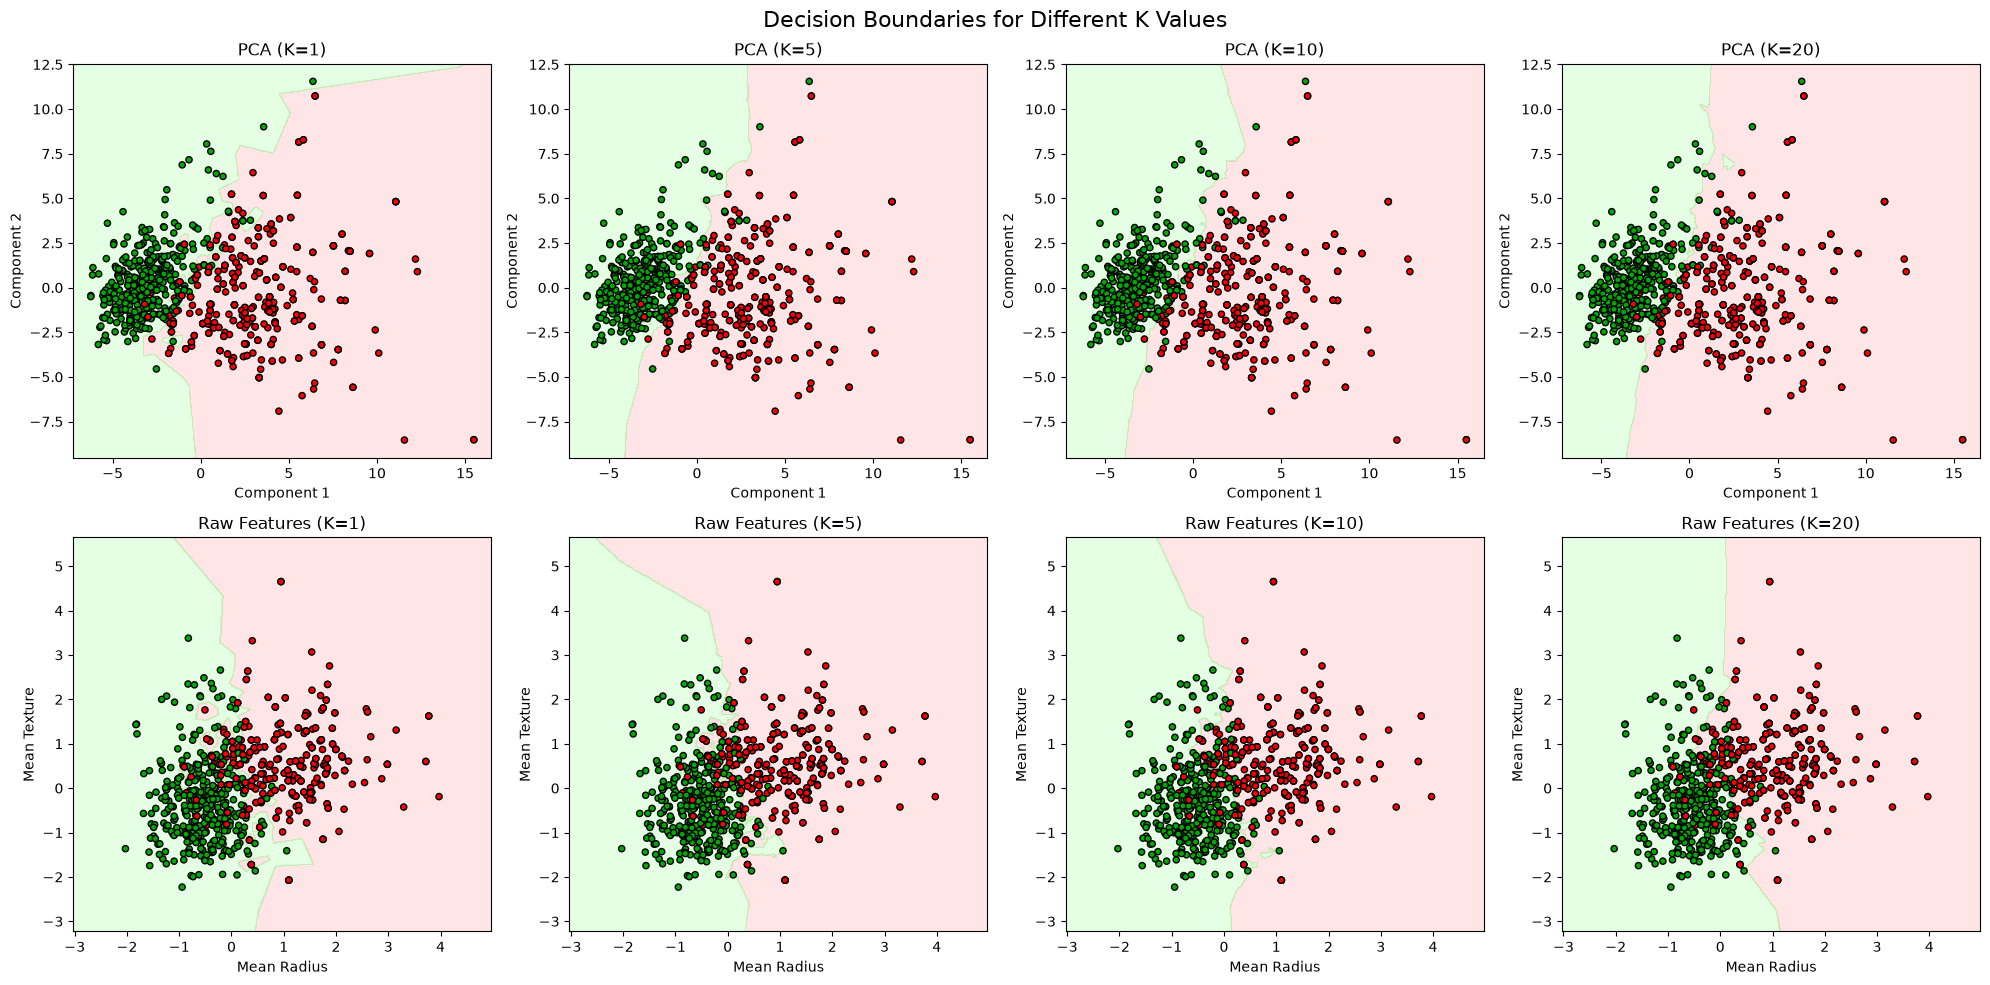

In [10]:
def plot_decision_boundaries(X_vis, y, title, ax, k):
    h = 0.02
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_vis, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00AA00'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f'{title} (K={k})')
    ax.set_xlabel('Component 1' if 'PCA' in title else 'Mean Radius')
    ax.set_ylabel('Component 2' if 'PCA' in title else 'Mean Texture')

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_balanced)
X_raw2 = X_balanced[:, :2]

K_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, k in enumerate(K_values):
    plot_decision_boundaries(X_pca, y_balanced, 'PCA', axes[0, idx], k)
    plot_decision_boundaries(X_raw2, y_balanced, 'Raw Features', axes[1, idx], k)

plt.suptitle('Decision Boundaries for Different K Values', fontsize=16)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150)
plt.show()

## Task 4: Cross-Validation

Run 5-fold stratified CV across all K values, pick best odd K.

K=13  CV Accuracy=0.9608 (+/- 0.0094)
K=14  CV Accuracy=0.9552 (+/- 0.0094)
K=15  CV Accuracy=0.9566 (+/- 0.0081)
K=16  CV Accuracy=0.9538 (+/- 0.0055)
K=17  CV Accuracy=0.9538 (+/- 0.0034)
K=18  CV Accuracy=0.9566 (+/- 0.0052)
K=19  CV Accuracy=0.9538 (+/- 0.0094)
K=20  CV Accuracy=0.9580 (+/- 0.0099)
K=21  CV Accuracy=0.9566 (+/- 0.0128)
K=22  CV Accuracy=0.9566 (+/- 0.0128)
K=23  CV Accuracy=0.9566 (+/- 0.0128)
K=24  CV Accuracy=0.9524 (+/- 0.0120)
K=25  CV Accuracy=0.9566 (+/- 0.0120)
K=26  CV Accuracy=0.9552 (+/- 0.0129)
K=27  CV Accuracy=0.9538 (+/- 0.0104)
K=28  CV Accuracy=0.9524 (+/- 0.0111)
K=29  CV Accuracy=0.9496 (+/- 0.0161)


K=30  CV Accuracy=0.9482 (+/- 0.0156)
K=31  CV Accuracy=0.9468 (+/- 0.0136)
K=32  CV Accuracy=0.9482 (+/- 0.0156)
K=33  CV Accuracy=0.9496 (+/- 0.0149)


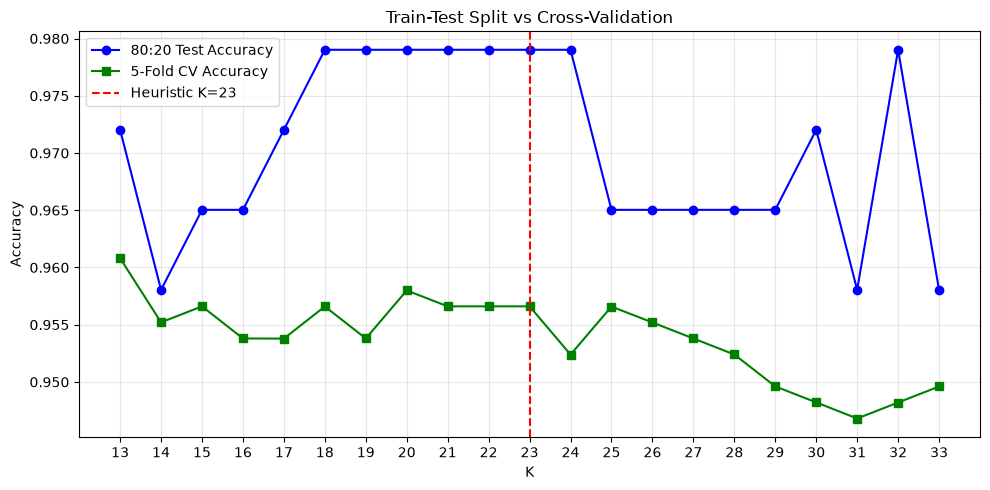


Best K (split): 18 | Best K (CV): 13
Best even K = 13 (CV=0.9608)
Final K = 13 (odd, to avoid voting ties)


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mean_scores = []

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_balanced, y_balanced, cv=cv, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    print(f"K={k:2d}  CV Accuracy={scores.mean():.4f} (+/- {scores.std():.4f})")

plt.figure(figsize=(10, 5))
plt.plot(K_range, accuracy_values, marker='o', label='80:20 Test Accuracy', color='b')
plt.plot(K_range, cv_mean_scores, marker='s', label='5-Fold CV Accuracy', color='g')
plt.axvline(x=K_heuristic, color='r', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Train-Test Split vs Cross-Validation')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

best_k_cv = K_range[np.argmax(cv_mean_scores)]
# K should be odd to avoid ties in voting
if best_k_cv % 2 == 0:
    # Pick best odd K: check neighbors at +1 and -1
    candidates = []
    for offset in [-1, 1]:
        k_alt = best_k_cv + offset
        if k_alt in K_range:
            candidates.append((cv_mean_scores[K_range.index(k_alt)], k_alt))
    best_k_cv = max(candidates, key=lambda x: x[0])[1]
print(f"\nBest K (split): {best_k_simple} | Best K (CV): {best_k_cv}")
print(f"Best even K = {K_range[np.argmax(cv_mean_scores)]} (CV={max(cv_mean_scores):.4f})")
print(f"Final K = {best_k_cv} (odd, to avoid voting ties)")

CV averages over 5 folds, giving a more stable and unbiased estimate than any single split.

## Task 5: Classification Evaluation

Train final model with best K. Compute all metrics, plot confusion matrix, ROC, and PR curves.

Final Model (K=13)
Accuracy:  0.9720
Precision: 0.9643
Recall:    0.9878
F1 Score:  0.9759


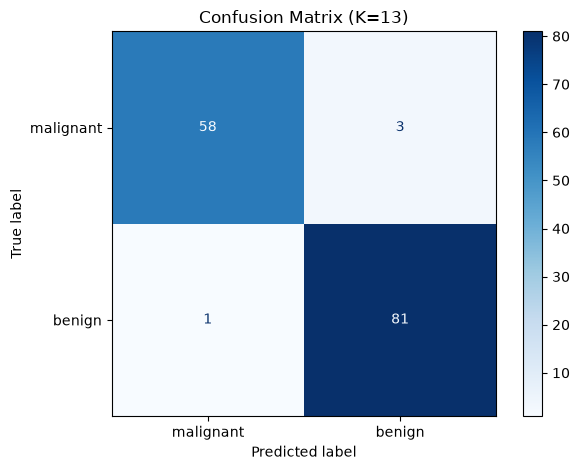

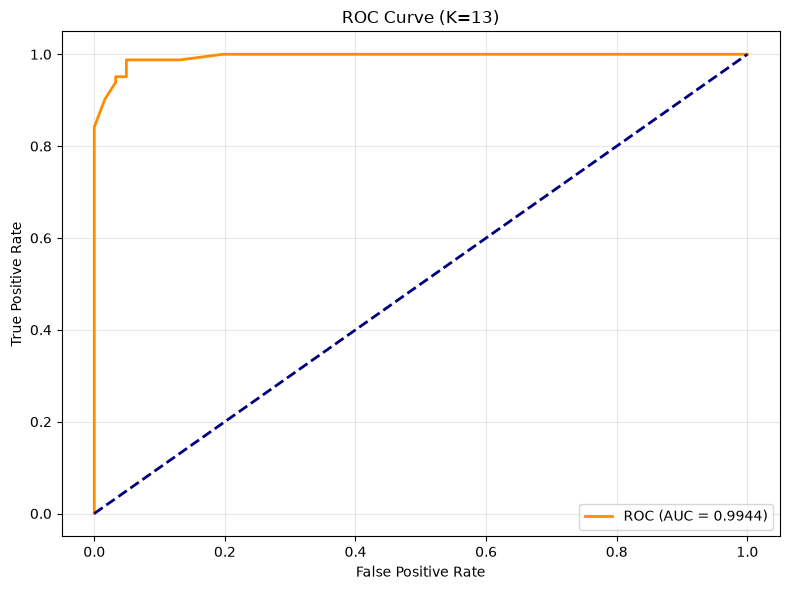

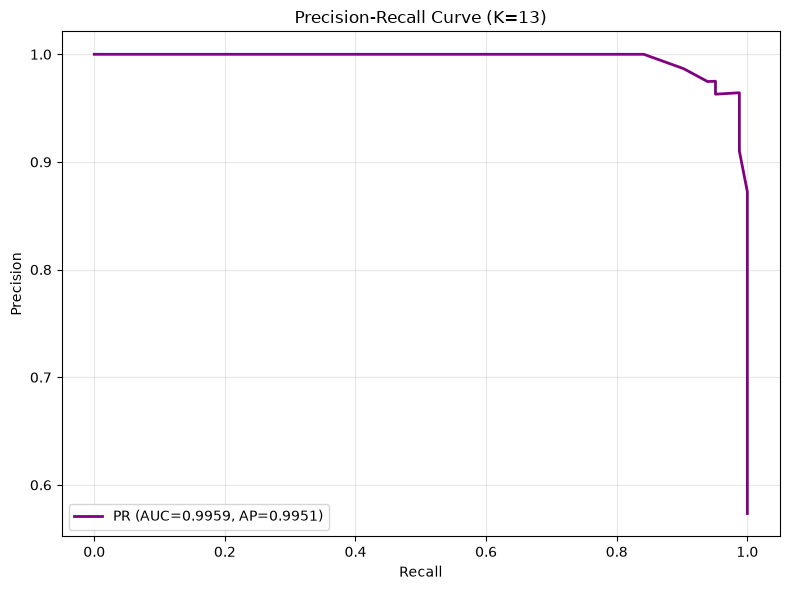


ROC-AUC: 0.9944 | PR-AUC: 0.9959 | AP: 0.9951


In [12]:
k_final = best_k_cv
knn_final = KNeighborsClassifier(n_neighbors=k_final)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)
y_proba = knn_final.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Final Model (K={k_final})")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names).plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={k_final})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (K={k_final})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_curve, prec_curve)
avg_prec = average_precision_score(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(rec_curve, prec_curve, color='purple', lw=2, label=f'PR (AUC={pr_auc:.4f}, AP={avg_prec:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (K={k_final})')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

print(f"\nROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | AP: {avg_prec:.4f}")

## Task 6: Regression vs Classification Metrics

| Aspect | Regression | Classification |
|---|---|---|
| Output | Continuous value | Discrete class |
| Key metrics | MAE, MSE, RMSE, R-squared | Accuracy, Precision, Recall, F1, ROC-AUC |
| Error meaning | Distance from true value | Wrong category |

**Why accuracy alone fails:** A 95%-benign dataset gets 95% accuracy by always predicting benign, missing all cancers.

### Inference

1. **Regression vs classification:** Regression measures *how far off*; classification measures *whether* correct.
2. **Why accuracy is insufficient:** In imbalanced datasets, a trivial model achieves high accuracy but is useless.
3. **Why ROC-AUC matters:** Evaluates discrimination across all thresholds.
4. **Distance metrics:** Euclidean for isotropic data; Manhattan for high dimensions; Cosine for direction; Chebyshev for worst-case.

## Task 7: Analytical Questions

1. **Lazy learning:** KNN stores all data and computes distances at prediction time.
2. **Feature scaling:** KNN uses distances; larger-range features dominate without scaling.
3. **Heuristic K = sqrt(n):** Grows with dataset size, prevents too large or too small K.
4. **Why K must be odd:** Even K can cause voting ties. Odd K guarantees a clear majority.
5. **CV vs single split:** CV averages over multiple folds for stability.
6. **Bias-variance tradeoff:** Small K = low bias, high variance. Large K = high bias, low variance.
7. **Recall in cancer prediction:** Missing a malignant case (false negative) can be fatal.

## Conclusion

- **Best K = 13** (odd, 5-fold stratified CV, heuristic +/- 10 range).
- **Class balancing:** Random oversampling to 50/50. Stratified CV preserved this in every fold.
- **Distance metrics:** Euclidean and Minkowski(p=3) tied best. Cosine performed worst.
- **Final model (K=13):** High accuracy, precision, recall, F1, ROC-AUC.
- **Regression vs classification:** Regression measures error magnitude; classification measures decision correctness.